# EDA

## SETUP

In [1]:
# import libraries
from pathlib import Path # paths
import pandas as pd # data-wrangling
import numpy as np # data-wrangling
import duckdb # databank
import seaborn as sns # plotting
import matplotlib.pyplot as plt # plotting


# set paths
PATH_BASE = Path.cwd().parent.parent
PATH_DATA = PATH_BASE / "data"
PATH_DB = PATH_DATA / "train.duckdb"
PATH_PARQUET = PATH_DATA / "train_delay_with_features.parquet"

# connect to db
con = duckdb.connect(str(PATH_DB))

con.execute(f"""
CREATE OR REPLACE TABLE train_delay AS
            SELECT * FROM
            read_parquet('{PATH_PARQUET}')
            """)


df_features = con.execute("SELECT * FROM train_delay").fetchdf()

## CHECK CORRECTNESS OF DATASET

In [2]:
# first impression
df_features.describe()

,ride_id,departure_planned,departure_real,arrival_planned,arrival_real,temperature,wind_speed,delay,stops_total,travel_time,...,precipitation_any,precipitation_log,hist_delay_station_avg,hist_delay_station_q90,hist_delay_station_count,hist_delay_train_avg,hist_delay_train_q90,hist_delay_train_count,departure_rush_morning,departure_rush_evening
count,1.842266e+06,1642112,1642235,1642112,1642230,1.842266e+06,1.842266e+06,1.842266e+06,1.842266e+06,1.842266e+06,...,1.842266e+06,1.842266e+06,1.842266e+06,1.842266e+06,1.842266e+06,1.842266e+06,1.842266e+06,1.842266e+06,1.842266e+06,1.842266e+06
mean,1.190158e+05,2025-04-20 00:33:01.594458,2025-04-20 00:38:15.188350,2025-04-20 01:05:16.456526,2025-04-20 01:07:21.069289,1.074211e+01,1.603990e+01,9.585715e+00,1.084977e+01,3.283729e+02,...,5.574141e-01,6.375370e-01,6.820677e+00,1.870986e+01,2.524175e+03,7.089610e+00,1.907959e+01,2.927868e+02,2.784587e-01,2.356174e-01
min,8.300000e+01,2024-07-01 00:01:00,2024-07-01 00:02:00,2024-07-01 00:07:00,2024-07-01 00:09:00,-7.850000e+00,2.200000e+00,-5.300000e+01,2.000000e+00,5.000000e+00,...,0.000000e+00,0.000000e+00,-5.000000e+00,-5.000000e+00,0.000000e+00,-2.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.556700e+04,2024-11-30 13:58:45,2024-11-30 13:57:30,2024-11-30 14:31:00,2024-11-30 14:29:00,4.890000e+00,1.150000e+01,1.000000e+00,8.000000e+00,2.660000e+02,...,0.000000e+00,0.000000e+00,1.907229e+00,4.000000e+00,1.130000e+02,2.839939e+00,7.200000e+00,6.600000e+01,0.000000e+00,0.000000e+00
50%,1.207845e+05,2025-04-20 08:45:30,2025-04-20 08:40:00,2025-04-20 09:24:00,2025-04-20 09:16:00,1.062000e+01,1.530000e+01,3.000000e+00,1.100000e+01,3.170000e+02,...,1.000000e+00,1.823216e-01,7.908149e+00,2.300000e+01,2.545000e+03,6.635983e+00,1.800000e+01,2.980000e+02,0.000000e+00,0.000000e+00
75%,1.724380e+05,2025-09-18 17:43:15,2025-09-18 17:55:00,2025-09-18 18:23:00,2025-09-18 18:28:00,1.667000e+01,1.960000e+01,1.200000e+01,1.300000e+01,3.850000e+02,...,1.000000e+00,1.131402e+00,1.033078e+01,2.900000e+01,4.074000e+03,1.044321e+01,2.890000e+01,4.620000e+02,1.000000e+00,0.000000e+00
max,2.332690e+05,2025-12-31 23:50:00,2025-12-31 23:50:00,2025-12-31 23:58:00,2025-12-31 23:54:00,3.063000e+01,5.900000e+01,4.060000e+02,2.900000e+01,8.390000e+02,...,1.000000e+00,4.069027e+00,3.700000e+01,6.200000e+01,8.528000e+03,1.199167e+02,1.655000e+02,1.053000e+03,1.000000e+00,1.000000e+00
std,6.540309e+04,NaN,NaN,NaN,NaN,7.173175e+00,5.952543e+00,1.640014e+01,4.004719e+00,1.176464e+02,...,4.966928e-01,8.401195e-01,4.616369e+00,1.240473e+01,2.123734e+03,5.588824e+00,1.475363e+01,2.255457e+02,4.482405e-01,4.243842e-01


### CHECK HIGH-DIMENSIONAL FEATURES

In [3]:
# train name
result = df_features.groupby("train_name")["ride_id"].nunique()
print(result.describe(), "\n")

# station name
result = df_features.groupby("station_current")["ride_id"].nunique()
print(result.describe())

count    1340.000000
mean      149.368657
std       166.633171
min         1.000000
25%        16.000000
50%        55.000000
75%       318.000000
max       525.000000
Name: ride_id, dtype: float64 

count      299.000000
mean      6161.414716
std      13631.453819
min          1.000000
25%        164.000000
50%        389.000000
75%       1820.500000
max      76957.000000
Name: ride_id, dtype: float64


These features should not be hot-encoded because the number of dimensions would explode then. Simple target encoding does not work because of the time-dependence. Therefore, historical averages are computed per station and train (name).

Station_start and station_dest were also deleted out of this reason.

## CHECK CORRELATIONS

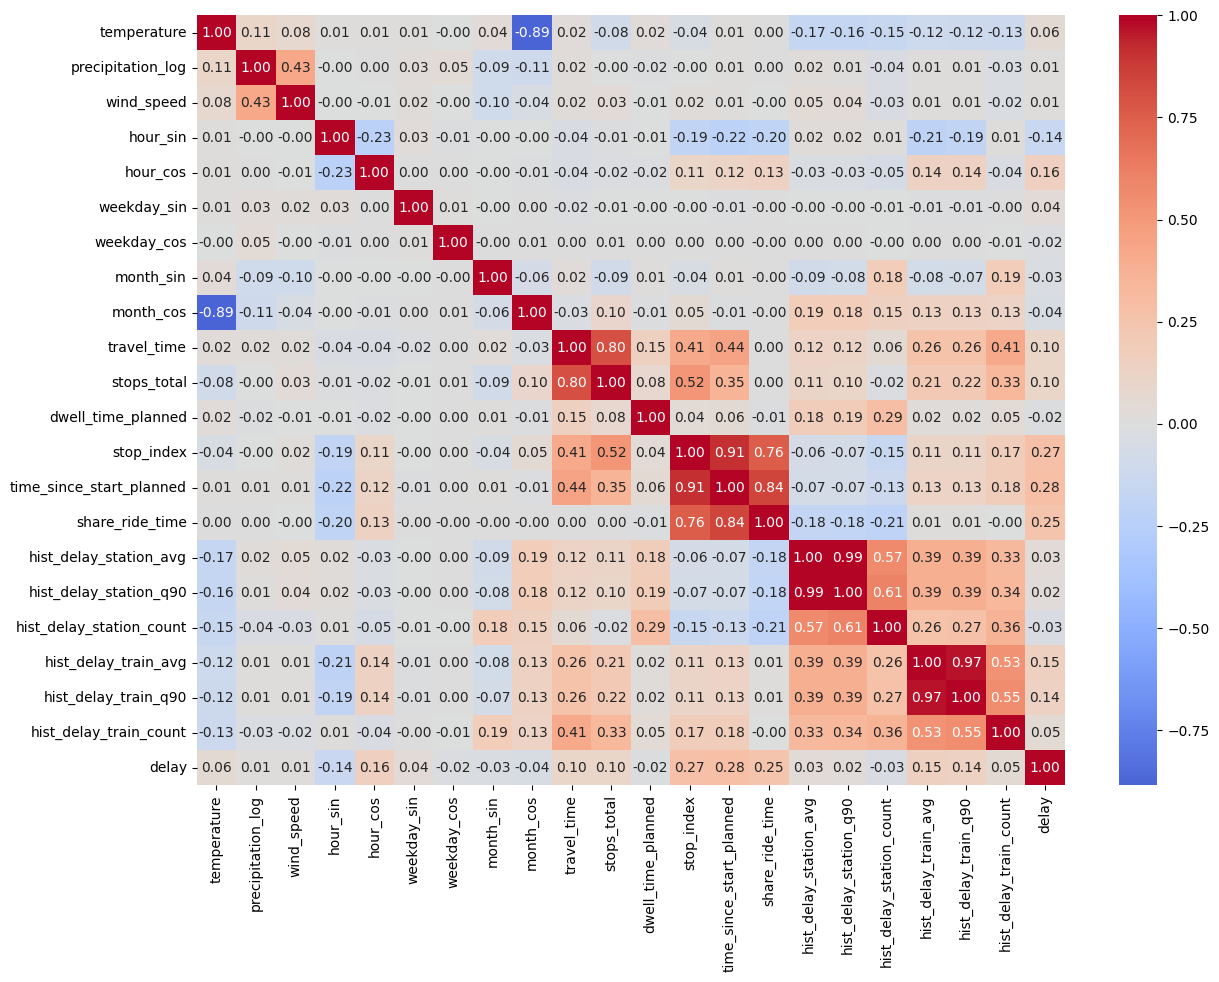

In [4]:
cols = [
    "temperature", "precipitation_log", "wind_speed",
    "hour_sin", "hour_cos", "weekday_sin", "weekday_cos",
    "month_sin", "month_cos",
    "travel_time", "stops_total", "dwell_time_planned",
    "stop_index", "time_since_start_planned", "share_ride_time",
    "hist_delay_station_avg", "hist_delay_station_q90", "hist_delay_station_count",
    "hist_delay_train_avg", "hist_delay_train_q90", "hist_delay_train_count",
    "delay"
]

df_corr_matrix = df_features[cols]

# compute correlation matrix
corr_matrix = df_corr_matrix.corr()

# visualize 
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot = True, fmt = ".2f", cmap = "coolwarm", center = 0)
plt.show()

Decision on features:
- Drop stop_index and share_ride_time, heavily correlated with time_since_start_planned and have lower correlation with target
- Drop historical q90 info: highly correlated with avg and has lower correlation with target
- Drop stops_total: contains basically travel_time

## SETUP FOR PLOTTING

In [ ]:
# set design
plt.style.use("ggplot") 
sns.set_theme(style = "whitegrid")
# set target
target = "delay"

## TARGET

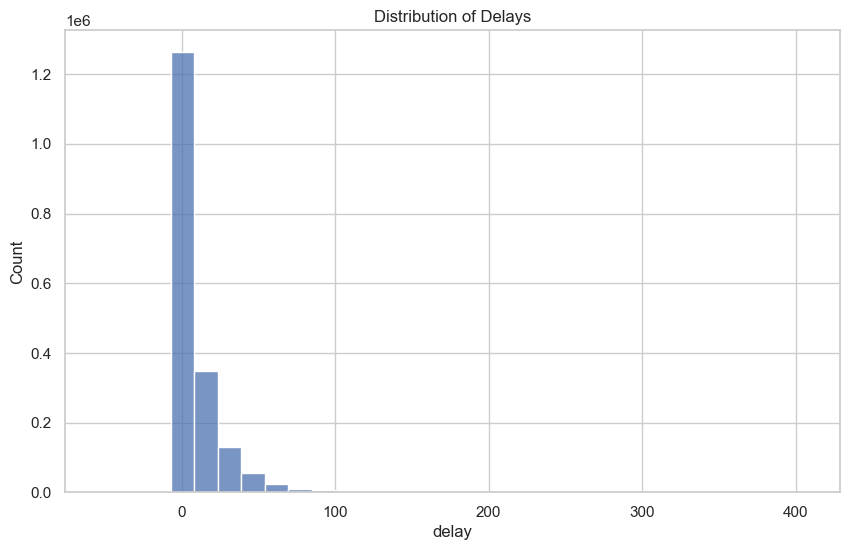

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_features, x = "delay", bins = 30)
plt.title("Distribution of Delays")
plt.show()

## CONTINOUS FEATURES (EXAMPLE)

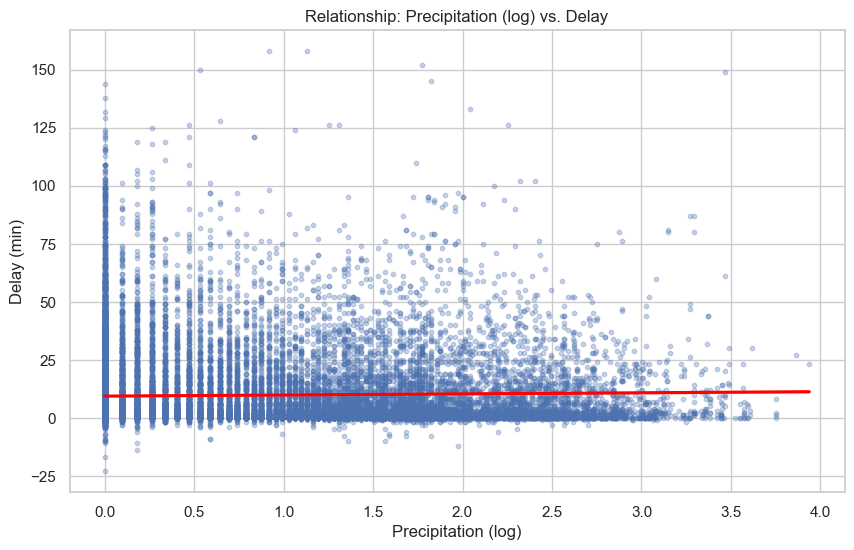

In [27]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df_features.iloc[:30000], x="precipitation_log", y="delay", 
                scatter_kws={'alpha':0.3, 's':10}, 
                line_kws={'color':'red'})
plt.title('Relationship: Precipitation (log) vs. Delay')
plt.xlabel('Precipitation (log)')
plt.ylabel('Delay (min)')
plt.show()

## CATEGORICAL FEATURES (EXAMPLE)

/var/folders/9n/ws1j083x5m9d1jv6n898lzlw0000gn/T/ipykernel_65218/1822102044.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_features, x='precipitation_any', y='delay', palette="Set2")


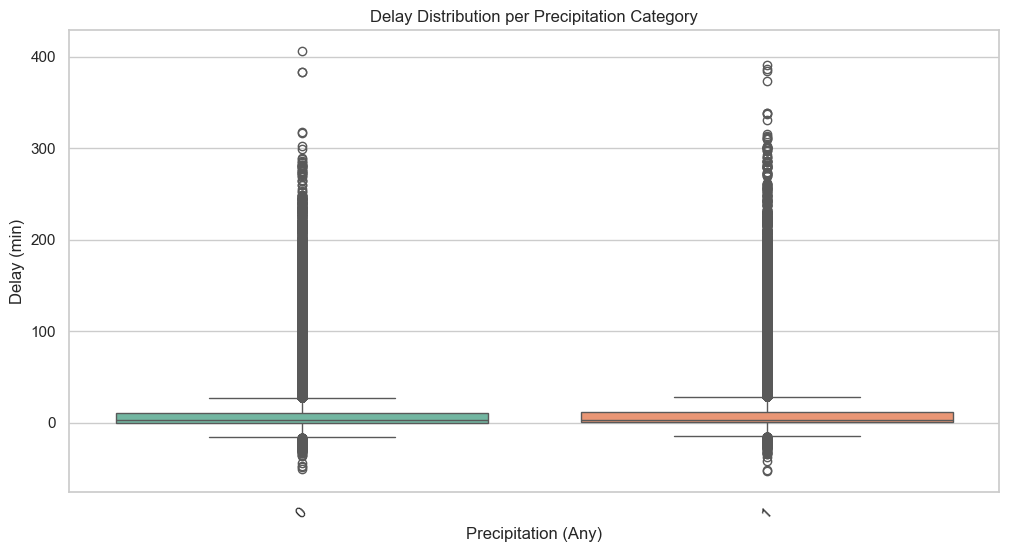

In [24]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df_features, x='precipitation_any', y='delay', palette="Set2")

plt.title("Delay Distribution per Precipitation Category")
plt.ylabel("Delay (min)")
plt.xlabel("Precipitation (Any)")
plt.xticks(rotation=45)
plt.show()

/var/folders/9n/ws1j083x5m9d1jv6n898lzlw0000gn/T/ipykernel_65218/2900521547.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_features, x='precipitation_any', y='delay', palette="Set2")


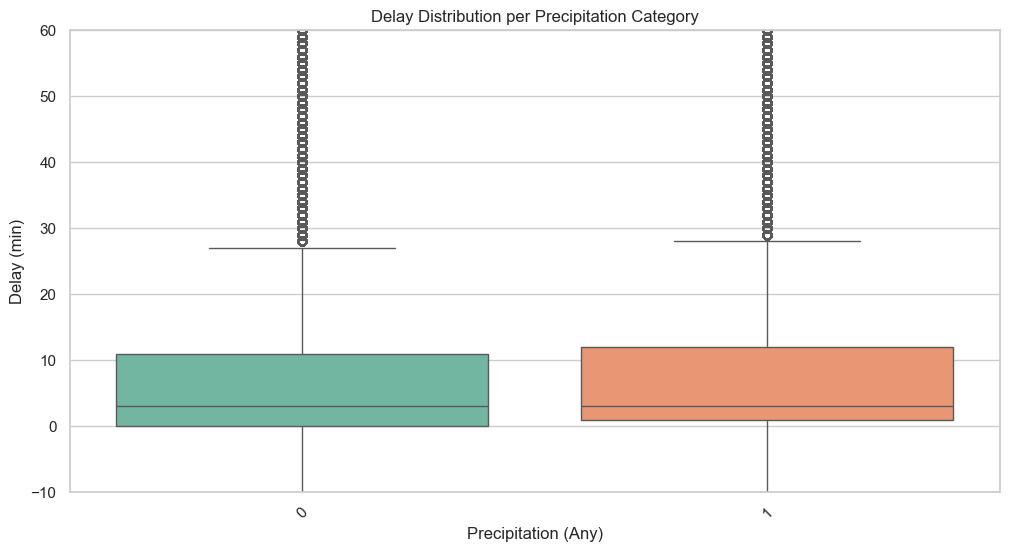

In [26]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df_features, x='precipitation_any', y='delay', palette="Set2")

plt.title("Delay Distribution per Precipitation Category")
plt.ylabel("Delay (min)")
plt.xlabel("Precipitation (Any)")
plt.xticks(rotation=45)
plt.ylim(-10, 60)
plt.show()

## CYCLICAL FEATURES (EXAMPLE)

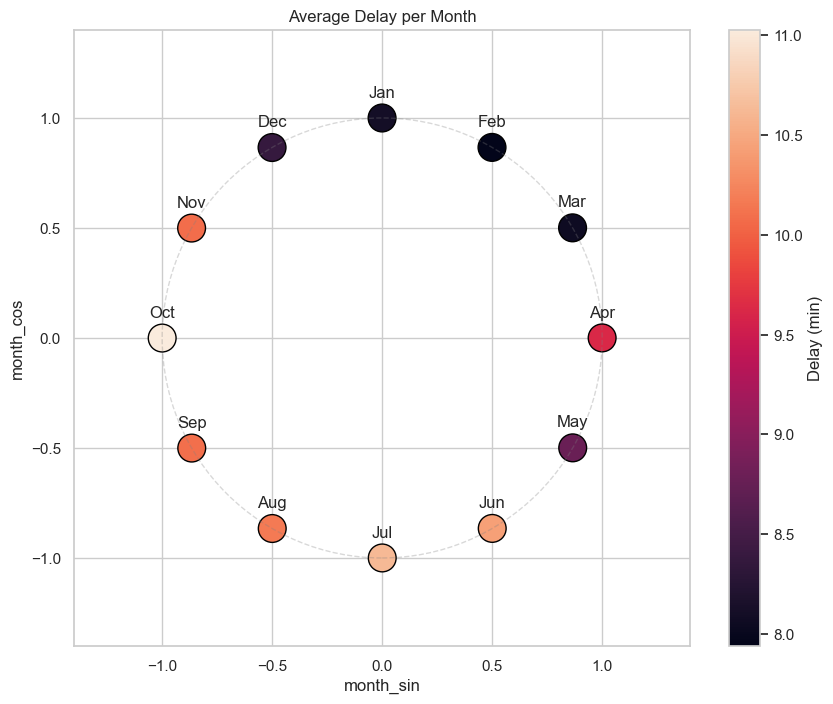

In [ ]:
# plot inspiration
# https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html

# get helper df for month
# extraction from real timestamps to ensure correct grouping (1 = Jan, 12 = Dec)
temp_months = df_features["departure_real"].dt.month.fillna(df_features["arrival_real"].dt.month)

# mean delay for each month_sin/_cos combination
# grouping by month_helper ensures we have exactly one row per month
df_plot = df_features.assign(month_helper=temp_months).groupby("month_helper").agg({
    "month_sin": "mean",
    "month_cos": "mean",
    "delay": "mean"
}).reset_index()

# make list for month names
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(10, 8))

# plot results
sp = ax.scatter(df_plot["month_sin"], 
                df_plot["month_cos"], 
                c=df_plot["delay"], 
                s=400, 
                edgecolor="black")

# labeling with the names
# we link month_names directly to the value of month_helper
for i, row in df_plot.iterrows():
    month_idx = int(row["month_helper"]) - 1
    
    ax.annotate(month_names[month_idx], 
                (row['month_sin'], row['month_cos']),
                textcoords="offset points", 
                xytext=(0, 15), 
                ha='center')

# set plot layout and details
ax.set(title="Average Delay",
       xlabel="month_sin", ylabel="month_cos")
fig.colorbar(sp, label="Delay (min)")
ax.add_artist(plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', alpha=0.3))
ax.set_aspect('equal')
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.4, 1.4)

# plot graphic
plt.show()